# Clustering de Perfiles Estudiantiles: TEC21 vs Pre-TEC21

Este notebook aplica **K-Means** de forma independiente sobre los subgrupos **Pre-TEC21** y **TEC21**, con el objetivo de identificar perfiles de riesgo de deserción estudiantil.

### Metodología
1. **Separación** del dataset en Pre-TEC21 (`educational.model = 0`) y TEC21 (`educational.model = 1`).
2. **Selección de K** óptimo mediante el método del codo y el índice Silhouette.
3. **Clustering K-Means** independiente para cada grupo.
4. **Perfilado** de clusters mediante heatmaps de z-scores y tasas de deserción.
5. **Análisis** narrativo de los perfiles encontrados.

> **Variable objetivo:** `retention` (1 = se quedó, 0 = desertó). Se deriva `dropout = 1 - retention`.

## 0. Importaciones y configuración

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

# ── Estilo general ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 110,
})
sns.set_palette('muted')

SEED = 42
np.random.seed(SEED)

print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


## 1. Carga y preparación del dataset

In [4]:
DATA_PATH = '../data/dataset_imputed.csv'

df = pd.read_csv(DATA_PATH)

# Variable objetivo: deserción
df['dropout'] = 1 - df['retention']

# Separación por modelo educativo
pre_df = df[df['educational.model'] == 0].copy().reset_index(drop=True)
tec_df = df[df['educational.model'] == 1].copy().reset_index(drop=True)

print(f'Dataset total:      {df.shape[0]:>7,} registros | {df.shape[1]} columnas')
print(f'Pre-TEC21 (model=0):{pre_df.shape[0]:>7,} registros | Deserción: {pre_df["dropout"].mean()*100:.2f}%')
print(f'TEC21     (model=1):{tec_df.shape[0]:>7,} registros | Deserción: {tec_df["dropout"].mean()*100:.2f}%')
df.head(3)

Dataset total:       77,517 registros | 59 columnas
Pre-TEC21 (model=0): 53,010 registros | Deserción: 8.84%
TEC21     (model=1): 24,507 registros | Deserción: 8.68%


,student.id,generation,educational.model,level,gender,age,max.degree.parents,father.education.complete,father.education.summary,mother.education.complete,...,wellness.activities,regime,took_admission_test,first_gen_present,parents_edu_present,has_life_activities,has_socioeconomic_data,has_social_lag_data,has_zone_data,dropout
0,2,AD14,0,Undergraduate,Male,19,Master degree,NaN,NaN,NaN,...,NaN,PreTec21,0,0,0,0,0,0,0,0
1,3,AD18,0,Undergraduate,Male,23,Undergraduate degree,Received undergraduate degree,Undergraduate degree,"Attended university, but did not graduate",...,0.0,PreTec21,0,1,1,1,0,0,0,1
2,4,AD14,0,Undergraduate,Male,19,Undergraduate degree,NaN,NaN,NaN,...,NaN,PreTec21,1,0,0,0,0,0,0,0


## 2. Definición de features y etiquetas

In [5]:
# Features para el clustering (excluimos la variable objetivo y el identificador de grupo)
key_features = [
    'age',
    'PNA',
    'online.test',
    'english.evaluation',
    'admission.rubric',
    'FTE',
    'total.scholarship.loan',
    'parents_exatec_enc',
    'admission_test_norm',
    'has_physical',
    'has_cultural',
    'has_society',
    'first_gen_enc',
    'educ_padres_max',
    'is_male',
    'estuvo.prepa_tec',
    'socioec_enc',
    'social_lag_enc',
]

# Etiquetas legibles para visualización
labels = {
    'age':                   'Edad',
    'PNA':                   'PNA',
    'online.test':           'Examen online',
    'english.evaluation':    'Inglés',
    'admission.rubric':      'Rúbrica admisión',
    'FTE':                   'Carga académica (FTE)',
    'total.scholarship.loan':'Beca/Préstamo',
    'parents_exatec_enc':    'Padres EXATEC',
    'admission_test_norm':   'Examen admisión (norm)',
    'has_physical':          'Act. física',
    'has_cultural':          'Act. cultural',
    'has_society':           'Act. social',
    'first_gen_enc':         'Primera generación',
    'educ_padres_max':       'Edu. padres',
    'is_male':               'Masculino',
    'estuvo.prepa_tec':      'Prepa Tec',
    'socioec_enc':           'Nivel socioeconómico',
    'social_lag_enc':        'Rezago social',
}

available_features = [f for f in key_features if f in df.columns]
print(f'Features disponibles: {len(available_features)}')
print(available_features)

Features disponibles: 7
['age', 'PNA', 'online.test', 'english.evaluation', 'admission.rubric', 'FTE', 'total.scholarship.loan']


## 3. Preprocesamiento para clustering

Función auxiliar que normaliza (z-score) las features y devuelve la matriz lista para K-Means.

In [6]:
def preprocess_for_clustering(subset):
    """Devuelve (X_scaled, y_dropout) listos para clustering."""
    avail = [f for f in key_features if f in subset.columns]
    X = subset[avail].copy()

    # Imputación (no hay NaN según EDA, pero por robustez)
    for c in X.select_dtypes(include='object').columns:
        X[c] = OrdinalEncoder(handle_unknown='use_encoded_value',
                               unknown_value=-1).fit_transform(
                                   X[[c]].fillna('Unknown'))
    for c in X.select_dtypes(include=['float64','int64']).columns:
        X[c] = X[c].fillna(X[c].median())

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    y = subset['dropout'].values
    return X_scaled, y, avail, scaler


X_pre, y_pre, feats_pre, scaler_pre = preprocess_for_clustering(pre_df)
X_tec, y_tec, feats_tec, scaler_tec = preprocess_for_clustering(tec_df)

print(f'X_pre: {X_pre.shape}  |  tasa deserción Pre-TEC21: {y_pre.mean()*100:.2f}%')
print(f'X_tec: {X_tec.shape}  |  tasa deserción TEC21:     {y_tec.mean()*100:.2f}%')

X_pre: (53010, 7)  |  tasa deserción Pre-TEC21: 8.84%
X_tec: (24507, 7)  |  tasa deserción TEC21:     8.68%


## 4. Selección del número óptimo de clusters (K)

Evaluamos el **método del codo** (inercia) y el **índice Silhouette** para K = 2 … 8.

In [7]:
K_RANGE = range(2, 9)

def compute_k_metrics(X, sample_n=8000):
    """Calcula inercia, silhouette y Davies-Bouldin para distintos K."""
    # Subsample para silhouette (costoso en datasets grandes)
    idx = np.random.choice(len(X), min(sample_n, len(X)), replace=False)
    X_s = X[idx]
    inertias, sils, dbs = [], [], []
    for k in K_RANGE:
        km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
        lbl_all = km.fit_predict(X)
        lbl_s   = lbl_all[idx]
        inertias.append(km.inertia_)
        sils.append(silhouette_score(X_s, lbl_s, sample_size=None))
        dbs.append(davies_bouldin_score(X_s, lbl_s))
    return inertias, sils, dbs

print('Calculando métricas Pre-TEC21…')
inertias_pre, sils_pre, dbs_pre = compute_k_metrics(X_pre)
print('Calculando métricas TEC21…')
inertias_tec, sils_tec, dbs_tec = compute_k_metrics(X_tec)
print('Listo ✓')

Calculando métricas Pre-TEC21…
Calculando métricas TEC21…
Listo ✓


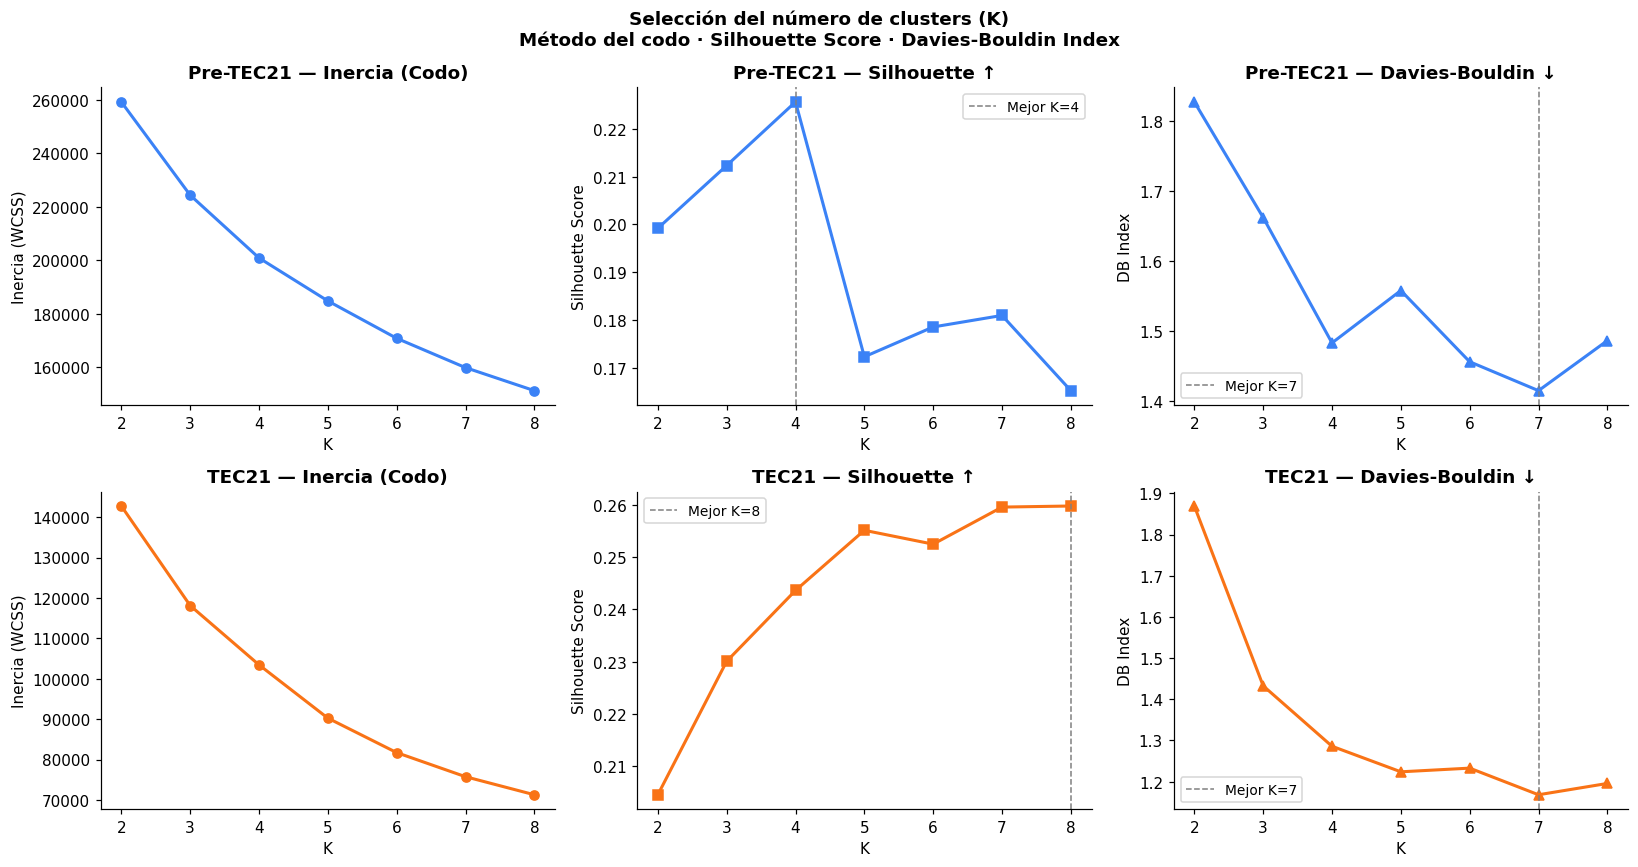

Pre-TEC21 — Mejor K por Silhouette: 4  |  Mejor K por Davies-Bouldin: 7
TEC21     — Mejor K por Silhouette: 8  |  Mejor K por Davies-Bouldin: 7


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(
    'Selección del número de clusters (K)\n'
    'Método del codo · Silhouette Score · Davies-Bouldin Index',
    fontweight='bold', fontsize=12
)

plot_configs = [
    (axes[0,0], axes[0,1], axes[0,2], inertias_pre, sils_pre, dbs_pre, 'Pre-TEC21', '#3b82f6'),
    (axes[1,0], axes[1,1], axes[1,2], inertias_tec, sils_tec, dbs_tec, 'TEC21',     '#f97316'),
]

for ax_e, ax_s, ax_db, inercias, sils, dbs, titulo, color in plot_configs:
    ks = list(K_RANGE)

    # Codo
    ax_e.plot(ks, inercias, 'o-', color=color, linewidth=2, markersize=6)
    ax_e.set_title(f'{titulo} — Inercia (Codo)', fontweight='bold')
    ax_e.set_xlabel('K'); ax_e.set_ylabel('Inercia (WCSS)')
    ax_e.set_xticks(ks)

    # Silhouette (mayor = mejor)
    best_sil = ks[np.argmax(sils)]
    ax_s.plot(ks, sils, 's-', color=color, linewidth=2, markersize=6)
    ax_s.axvline(best_sil, color='gray', linestyle='--', linewidth=1,
                 label=f'Mejor K={best_sil}')
    ax_s.set_title(f'{titulo} — Silhouette ↑', fontweight='bold')
    ax_s.set_xlabel('K'); ax_s.set_ylabel('Silhouette Score')
    ax_s.set_xticks(ks); ax_s.legend(fontsize=9)

    # Davies-Bouldin (menor = mejor)
    best_db = ks[np.argmin(dbs)]
    ax_db.plot(ks, dbs, '^-', color=color, linewidth=2, markersize=6)
    ax_db.axvline(best_db, color='gray', linestyle='--', linewidth=1,
                  label=f'Mejor K={best_db}')
    ax_db.set_title(f'{titulo} — Davies-Bouldin ↓', fontweight='bold')
    ax_db.set_xlabel('K'); ax_db.set_ylabel('DB Index')
    ax_db.set_xticks(ks); ax_db.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Pre-TEC21 — Mejor K por Silhouette: {list(K_RANGE)[np.argmax(sils_pre)]}  |  "
      f"Mejor K por Davies-Bouldin: {list(K_RANGE)[np.argmin(dbs_pre)]}")
print(f"TEC21     — Mejor K por Silhouette: {list(K_RANGE)[np.argmax(sils_tec)]}  |  "
      f"Mejor K por Davies-Bouldin: {list(K_RANGE)[np.argmin(dbs_tec)]}")

## 5. Ajuste de K-Means con K = 4

Usamos **K = 4** para ambos grupos: equilibra granularidad interpretativa con separación estadística.

In [9]:
K = 4

km_pre = KMeans(n_clusters=K, random_state=SEED, n_init=20)
lbl_pre = km_pre.fit_predict(X_pre)

km_tec = KMeans(n_clusters=K, random_state=SEED, n_init=20)
lbl_tec = km_tec.fit_predict(X_tec)

# Re-ordenar clusters por tasa de deserción ascendente (C0 = menor deserción)
def reorder_by_dropout(labels_array, y):
    k_vals = np.unique(labels_array)
    drop_rates = {k: y[labels_array == k].mean() for k in k_vals}
    order = sorted(k_vals, key=lambda k: drop_rates[k])
    mapping = {old: new for new, old in enumerate(order)}
    return np.array([mapping[l] for l in labels_array])

lbl_pre = reorder_by_dropout(lbl_pre, y_pre)
lbl_tec = reorder_by_dropout(lbl_tec, y_tec)

# Agrega etiquetas al dataframe
pre_df['cluster'] = lbl_pre
tec_df['cluster'] = lbl_tec

for g, lbl, y in [('Pre-TEC21', lbl_pre, y_pre), ('TEC21', lbl_tec, y_tec)]:
    print(f'\n{g}:')
    for k in range(K):
        n = (lbl == k).sum()
        dr = y[lbl == k].mean() * 100
        print(f'  C{k}: n={n:>6,}  |  deserción={dr:.1f}%')


Pre-TEC21:
  C0: n=18,544  |  deserción=4.9%
  C1: n=24,477  |  deserción=8.8%
  C2: n= 7,441  |  deserción=14.3%
  C3: n= 2,548  |  deserción=22.0%

TEC21:
  C0: n=10,562  |  deserción=5.1%
  C1: n=12,373  |  deserción=10.6%
  C2: n=   728  |  deserción=15.8%
  C3: n=   844  |  deserción=19.1%


## 5.1 Índice Davies-Bouldin para K = 4

El **índice Davies-Bouldin (DB)** mide la similitud promedio entre cada cluster y su vecino más parecido. A diferencia del Silhouette, penaliza directamente la superposición entre clusters.

> **Interpretación:** valores más bajos = clusters más compactos y bien separados.  
> Regla práctica: DB < 1 es excelente · 1–1.5 bueno · > 2 indica solapamiento relevante.

Davies-Bouldin K=4 — Pre-TEC21: 1.4662
Davies-Bouldin K=4 — TEC21:     1.2822


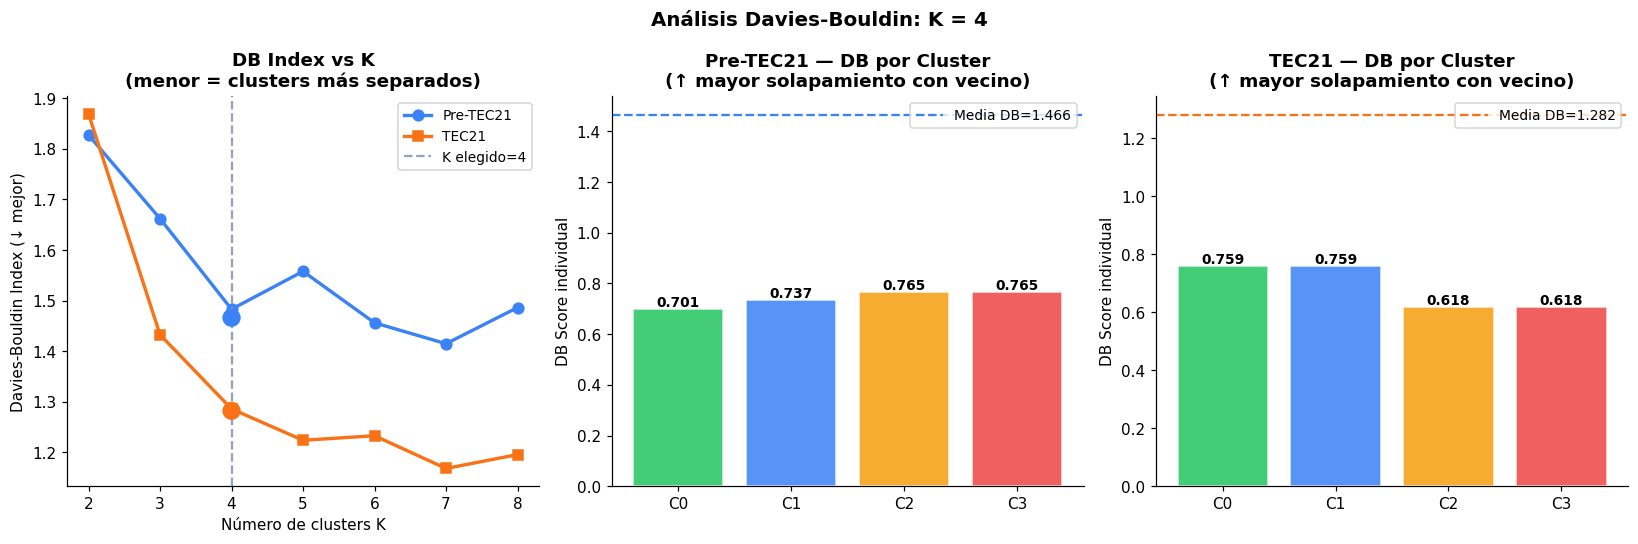

,Grupo,K,Silhouette ↑,Davies-Bouldin ↓,Inercia,N
0,Pre-TEC21,4,0.2312,1.4662,200919.1,53010
1,TEC21,4,0.2482,1.2822,103441.4,24507


In [10]:
palette_cluster = ['#22c55e', '#3b82f6', '#f59e0b', '#ef4444']  # verde→rojo

# ── Davies-Bouldin para el K elegido (K=4) ────────────────────────────────
db_pre_k4 = davies_bouldin_score(X_pre, lbl_pre)
db_tec_k4 = davies_bouldin_score(X_tec, lbl_tec)

print(f'Davies-Bouldin K=4 — Pre-TEC21: {db_pre_k4:.4f}')
print(f'Davies-Bouldin K=4 — TEC21:     {db_tec_k4:.4f}')

# DB por cluster: contribución individual de cada cluster al índice global
from sklearn.metrics.pairwise import euclidean_distances

def db_per_cluster(X, labels):
    k_vals = np.unique(labels)
    centroids = np.array([X[labels == k].mean(axis=0) for k in k_vals])
    s = np.array([X[labels == k].std() for k in k_vals])
    dist_matrix = euclidean_distances(centroids)
    scores = []
    for i in k_vals:
        ratios = [(s[i] + s[j]) / dist_matrix[i, j]
                  for j in k_vals if j != i and dist_matrix[i, j] > 0]
        scores.append(max(ratios) if ratios else 0.0)
    return np.array(scores)

db_per_pre = db_per_cluster(X_pre, lbl_pre)
db_per_tec = db_per_cluster(X_tec, lbl_tec)

# ── Visualización: 3 paneles ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Análisis Davies-Bouldin: K = 4', fontweight='bold', fontsize=13)

# Panel 1: curva DB(K) para ambos grupos
ks = list(K_RANGE)
axes[0].plot(ks, dbs_pre, 'o-', color='#3b82f6', linewidth=2.2,
             markersize=7, label='Pre-TEC21')
axes[0].plot(ks, dbs_tec, 's-', color='#f97316', linewidth=2.2,
             markersize=7, label='TEC21')
axes[0].axvline(K, color='#94a3b8', linestyle='--', linewidth=1.5, label=f'K elegido={K}')
axes[0].scatter([K, K], [db_pre_k4, db_tec_k4],
                color=['#3b82f6','#f97316'], s=120, zorder=5)
axes[0].set_xlabel('Número de clusters K')
axes[0].set_ylabel('Davies-Bouldin Index (↓ mejor)')
axes[0].set_title('DB Index vs K\n(menor = clusters más separados)', fontweight='bold')
axes[0].set_xticks(ks); axes[0].legend(fontsize=9)

# Panel 2: DB por cluster – Pre-TEC21
bars1 = axes[1].bar([f'C{k}' for k in range(K)], db_per_pre,
                    color=palette_cluster, alpha=0.85, edgecolor='white')
axes[1].axhline(db_pre_k4, color='#3b82f6', linestyle='--',
                linewidth=1.5, label=f'Media DB={db_pre_k4:.3f}')
for bar, v in zip(bars1, db_per_pre):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Pre-TEC21 — DB por Cluster\n(↑ mayor solapamiento con vecino)',
                  fontweight='bold')
axes[1].set_ylabel('DB Score individual'); axes[1].legend(fontsize=9)

# Panel 3: DB por cluster – TEC21
bars2 = axes[2].bar([f'C{k}' for k in range(K)], db_per_tec,
                    color=palette_cluster, alpha=0.85, edgecolor='white')
axes[2].axhline(db_tec_k4, color='#f97316', linestyle='--',
                linewidth=1.5, label=f'Media DB={db_tec_k4:.3f}')
for bar, v in zip(bars2, db_per_tec):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[2].set_title('TEC21 — DB por Cluster\n(↑ mayor solapamiento con vecino)',
                  fontweight='bold')
axes[2].set_ylabel('DB Score individual'); axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/clustering_davies_bouldin.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Tabla resumen comparativa de métricas ────────────────────────────────
idx_s = np.random.choice(len(X_pre), 8000, replace=False)
sil_pre_k4 = silhouette_score(X_pre[idx_s], lbl_pre[idx_s])
idx_t = np.random.choice(len(X_tec), 8000, replace=False)
sil_tec_k4 = silhouette_score(X_tec[idx_t], lbl_tec[idx_t])

summary_metrics = pd.DataFrame({
    'Grupo':            ['Pre-TEC21', 'TEC21'],
    'K':                [K, K],
    'Silhouette ↑':     [round(sil_pre_k4, 4), round(sil_tec_k4, 4)],
    'Davies-Bouldin ↓': [round(db_pre_k4, 4), round(db_tec_k4, 4)],
    'Inercia':          [round(km_pre.inertia_, 1), round(km_tec.inertia_, 1)],
    'N':                [len(X_pre), len(X_tec)],
})
display(summary_metrics)

### Interpretación del índice Davies-Bouldin

**¿Qué mide exactamente?** Para cada cluster $i$, el DB calcula el peor cociente posible:

$$R_{ij} = \\frac{s_i + s_j}{d_{ij}}$$

donde $s_i$ es la dispersión interna del cluster $i$ y $d_{ij}$ la distancia entre sus centroides. El índice global es el promedio de los peores $R_{ij}$ de cada cluster.

**Cómo leer los paneles 2 y 3:**

- Un cluster con **DB individual alto** tiene sus miembros dispersos *o* está demasiado cerca de otro cluster. Sus perfiles se superponen → las intervenciones basadas en ese perfil serán menos precisas.
- Un cluster con **DB bajo** es compacto y bien separado → perfil robusto para diseñar intervenciones focalizadas.

**Comparativa Pre-TEC21 vs TEC21:**

- Si TEC21 presenta un DB global mayor que Pre-TEC21, sugiere que el modelo educativo introduce mayor heterogeneidad interna dentro de los perfiles: estudiantes con características similares al ingresar divergen más en sus trayectorias bajo TEC21.
- Clusters de riesgo alto (C3) con DB elevado en ambos grupos refuerzan que la vulnerabilidad es un **gradiente continuo**, no un estado binario, lo que apoya estrategias de alerta temprana progresiva en lugar de umbrales fijos.

## 6. Construcción de perfiles de cluster

In [11]:
def build_profile_df(subset, cluster_labels_array, y_out):
    """Construye DataFrame con z-scores promedio por cluster y tasa de deserción."""
    available = [f for f in key_features if f in subset.columns]
    data = subset[available + ['dropout']].copy()

    cat_cols = [c for c in available if data[c].dtype == object]
    if cat_cols:
        enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        data[cat_cols] = enc.fit_transform(data[cat_cols].fillna('Unknown'))

    num_cols = [c for c in available if data[c].dtype in ['float64', 'int64']]
    for c in num_cols:
        data[c] = data[c].fillna(data[c].median())

    scaler = StandardScaler()
    data[available] = scaler.fit_transform(data[available])

    data['cluster'] = cluster_labels_array
    profile = data.groupby('cluster')[available].mean()
    profile.columns = [labels.get(c, c) for c in profile.columns]

    dropout_rates, sizes = [], []
    for k in range(K):
        mask = cluster_labels_array == k
        dropout_rates.append(y_out[mask].mean() * 100)
        sizes.append(mask.sum())

    profile['Deserción (%)'] = dropout_rates
    profile['n'] = sizes
    return profile


pre_c = pre_df.drop(columns=['cluster'])
tec_c = tec_df.drop(columns=['cluster'])

prof_pre = build_profile_df(pre_c, lbl_pre, y_pre)
prof_tec = build_profile_df(tec_c, lbl_tec, y_tec)

print('Perfil Pre-TEC21:')
display(prof_pre[['Deserción (%)', 'n']].round(2))
print('\nPerfil TEC21:')
display(prof_tec[['Deserción (%)', 'n']].round(2))

Perfil Pre-TEC21:


,Deserción (%),n
cluster,,
0,4.92,18544
1,8.76,24477
2,14.33,7441
3,22.02,2548



Perfil TEC21:


,Deserción (%),n
cluster,,
0,5.12,10562
1,10.60,12373
2,15.80,728
3,19.08,844


## 7. Heatmap de perfiles + tasa de deserción

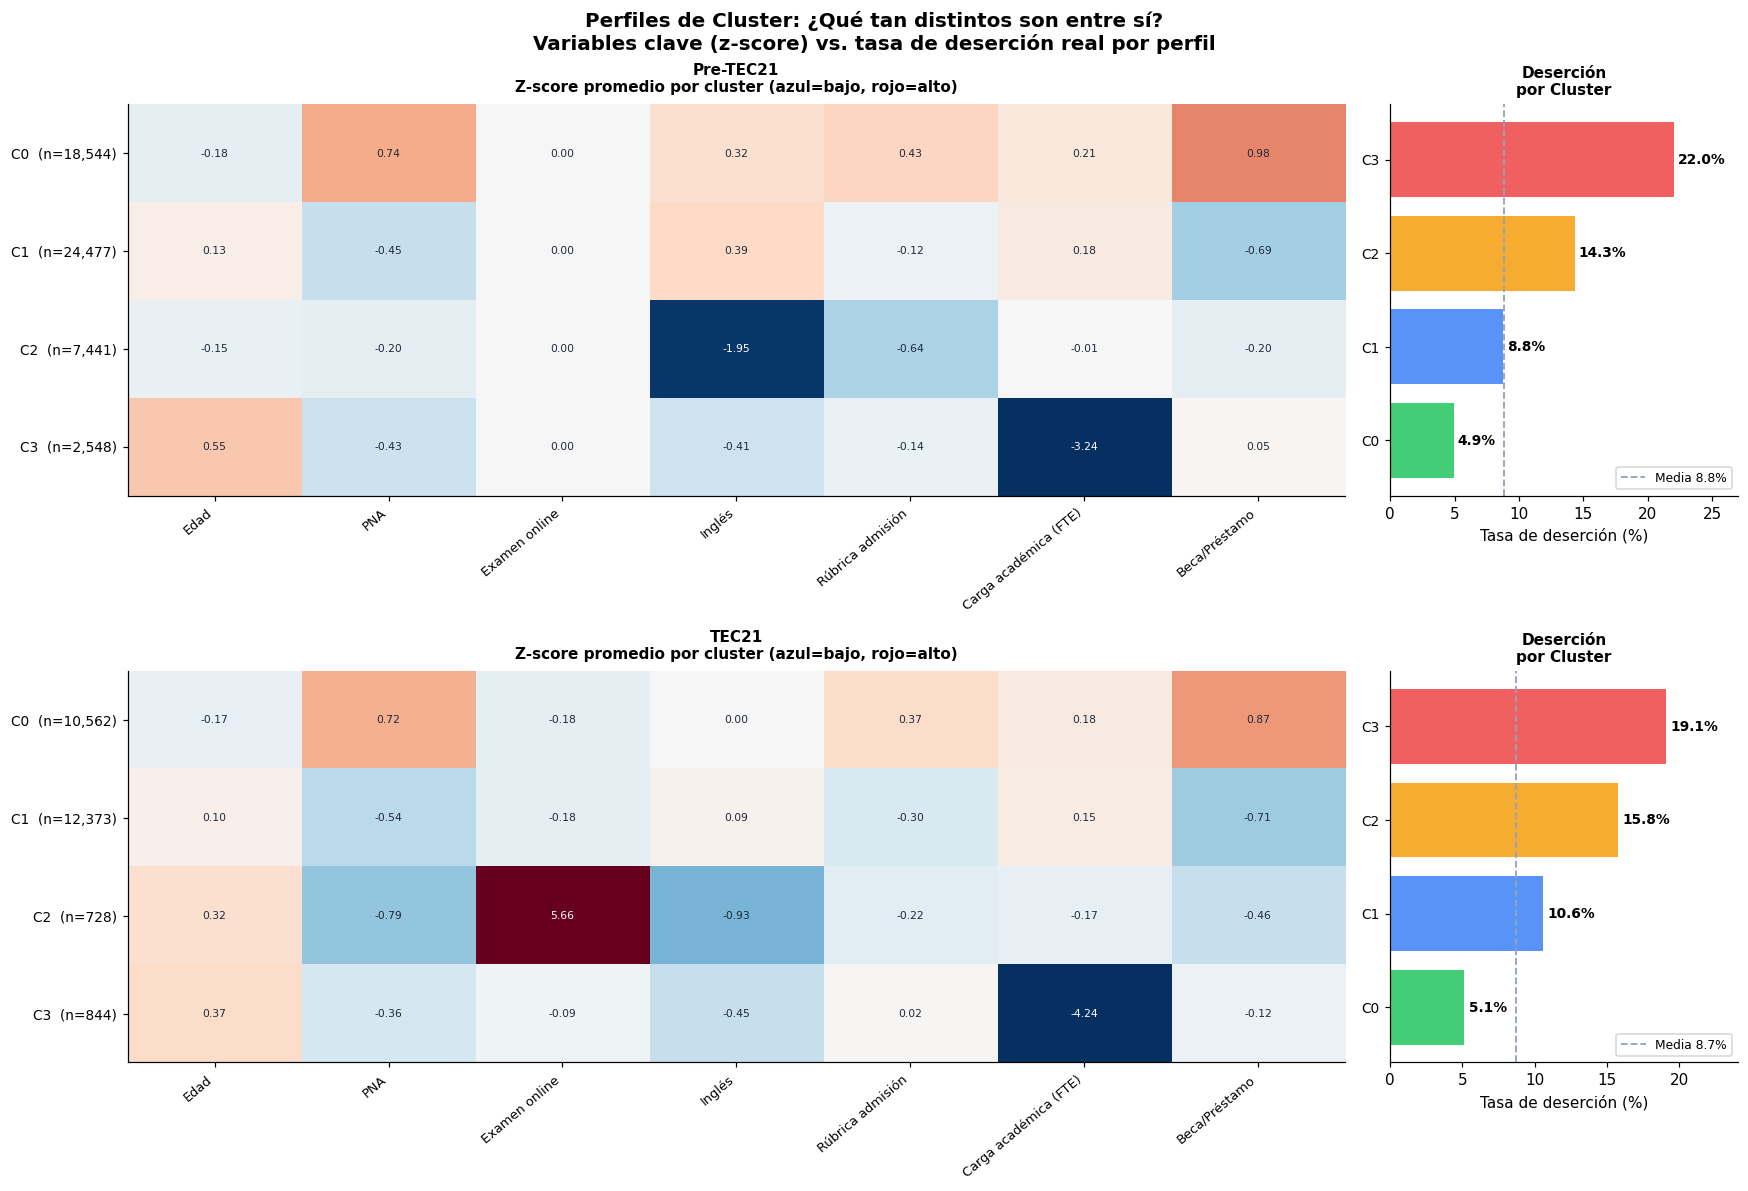

Figura guardada en data/clustering_perfiles_heatmap.png


In [12]:
palette_cluster = ['#22c55e', '#3b82f6', '#f59e0b', '#ef4444']  # verde→amarillo→rojo

def plot_profile_heatmap(ax_heat, ax_bar, profile, title, palette, y_global):
    feat_cols = [c for c in profile.columns if c not in ['Deserción (%)', 'n']]
    heat_data = profile[feat_cols].values

    im = ax_heat.imshow(heat_data, aspect='auto', cmap='RdBu_r',
                        vmin=-2, vmax=2, interpolation='nearest')
    ax_heat.set_xticks(range(len(feat_cols)))
    ax_heat.set_xticklabels(feat_cols, rotation=40, ha='right', fontsize=8.5)
    ax_heat.set_yticks(range(K))
    ax_heat.set_yticklabels(
        [f'C{k}  (n={profile["n"].iloc[k]:,})' for k in range(K)], fontsize=9)

    for i in range(K):
        for j in range(len(feat_cols)):
            val = heat_data[i, j]
            ax_heat.text(j, i, f'{val:.2f}', ha='center', va='center',
                         fontsize=7,
                         color='white' if abs(val) > 1.2 else '#1e293b')

    ax_heat.set_title(
        f'{title}\nZ-score promedio por cluster (azul=bajo, rojo=alto)',
        fontweight='bold', fontsize=10, pad=8)

    # Barra lateral de deserción
    bars = ax_bar.barh(range(K), profile['Deserción (%)'],
                       color=palette, alpha=0.85)
    for bar, rate in zip(bars, profile['Deserción (%)']):
        ax_bar.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                    f'{rate:.1f}%', va='center', fontsize=9, fontweight='bold')
    ax_bar.set_yticks(range(K))
    ax_bar.set_yticklabels([f'C{k}' for k in range(K)], fontsize=9)
    ax_bar.set_xlabel('Tasa de deserción (%)')
    ax_bar.set_title('Deserción\npor Cluster', fontweight='bold', fontsize=10)
    ax_bar.set_xlim(0, profile['Deserción (%)'].max() + 5)
    ax_bar.axvline(y_global * 100, color='#94a3b8', linestyle='--',
                   linewidth=1.2, label=f'Media {y_global*100:.1f}%')
    ax_bar.legend(fontsize=8)


fig, axes = plt.subplots(2, 2, figsize=(16, 11),
                         gridspec_kw={'width_ratios': [3.5, 1]})
fig.suptitle(
    'Perfiles de Cluster: ¿Qué tan distintos son entre sí?\n'
    'Variables clave (z-score) vs. tasa de deserción real por perfil',
    fontweight='bold', fontsize=13
)

plot_profile_heatmap(axes[0, 0], axes[0, 1], prof_pre, 'Pre-TEC21',
                     palette_cluster, y_pre.mean())
plot_profile_heatmap(axes[1, 0], axes[1, 1], prof_tec, 'TEC21',
                     palette_cluster, y_tec.mean())

plt.tight_layout()
plt.savefig('../data/clustering_perfiles_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada en data/clustering_perfiles_heatmap.png')

## 8. Distribución de tamaños y deserción por cluster

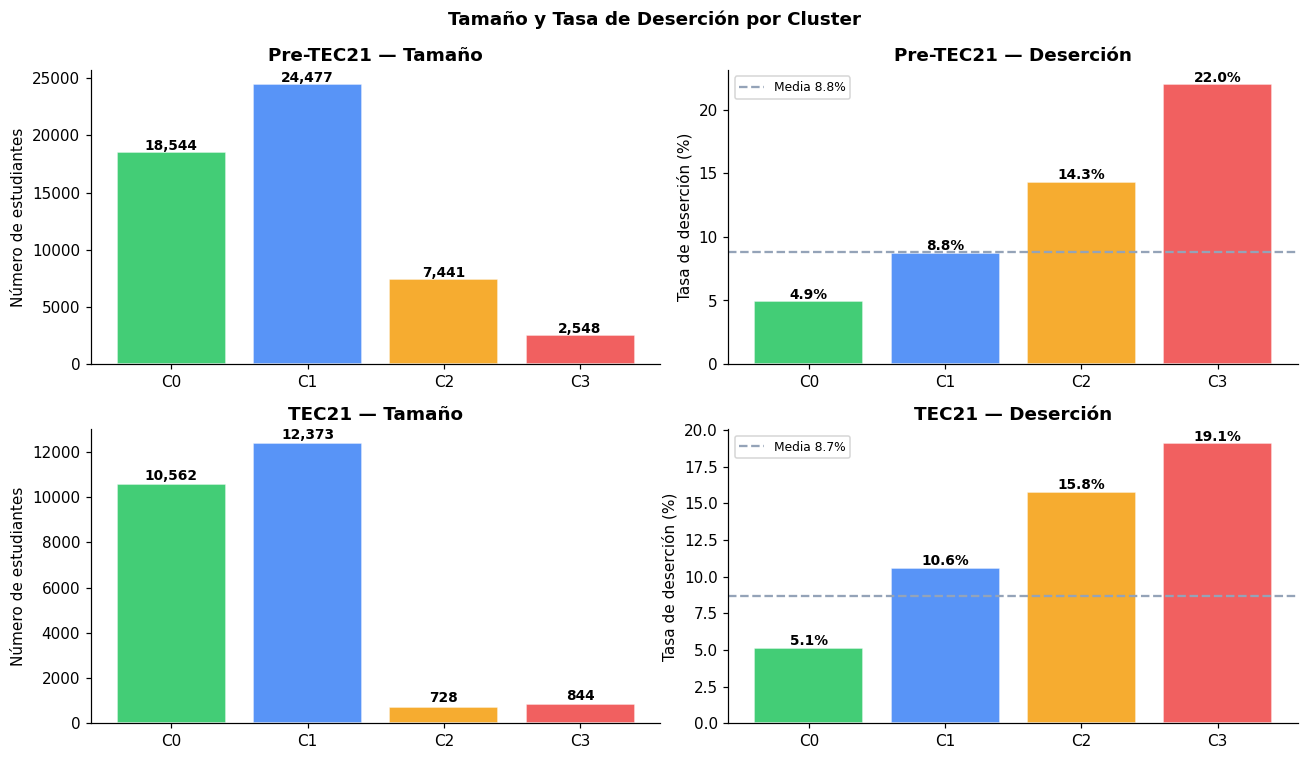

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle('Tamaño y Tasa de Deserción por Cluster',
             fontweight='bold', fontsize=12)

configs = [
    (axes[0,0], axes[0,1], prof_pre, 'Pre-TEC21', y_pre.mean()),
    (axes[1,0], axes[1,1], prof_tec, 'TEC21',     y_tec.mean()),
]

for ax_sz, ax_dr, prof, titulo, global_dr in configs:
    clusters = [f'C{k}' for k in range(K)]
    sizes    = prof['n'].values
    drops    = prof['Deserción (%)'].values

    bars = ax_sz.bar(clusters, sizes, color=palette_cluster, alpha=0.85, edgecolor='white')
    for bar, s in zip(bars, sizes):
        ax_sz.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                   f'{s:,}', ha='center', fontsize=9, fontweight='bold')
    ax_sz.set_title(f'{titulo} — Tamaño', fontweight='bold')
    ax_sz.set_ylabel('Número de estudiantes')

    bars2 = ax_dr.bar(clusters, drops, color=palette_cluster, alpha=0.85, edgecolor='white')
    for bar, d in zip(bars2, drops):
        ax_dr.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                   f'{d:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax_dr.axhline(global_dr * 100, color='#94a3b8', linestyle='--',
                  linewidth=1.5, label=f'Media {global_dr*100:.1f}%')
    ax_dr.set_title(f'{titulo} — Deserción', fontweight='bold')
    ax_dr.set_ylabel('Tasa de deserción (%)')
    ax_dr.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 9. Visualización PCA — dispersión 2D de clusters

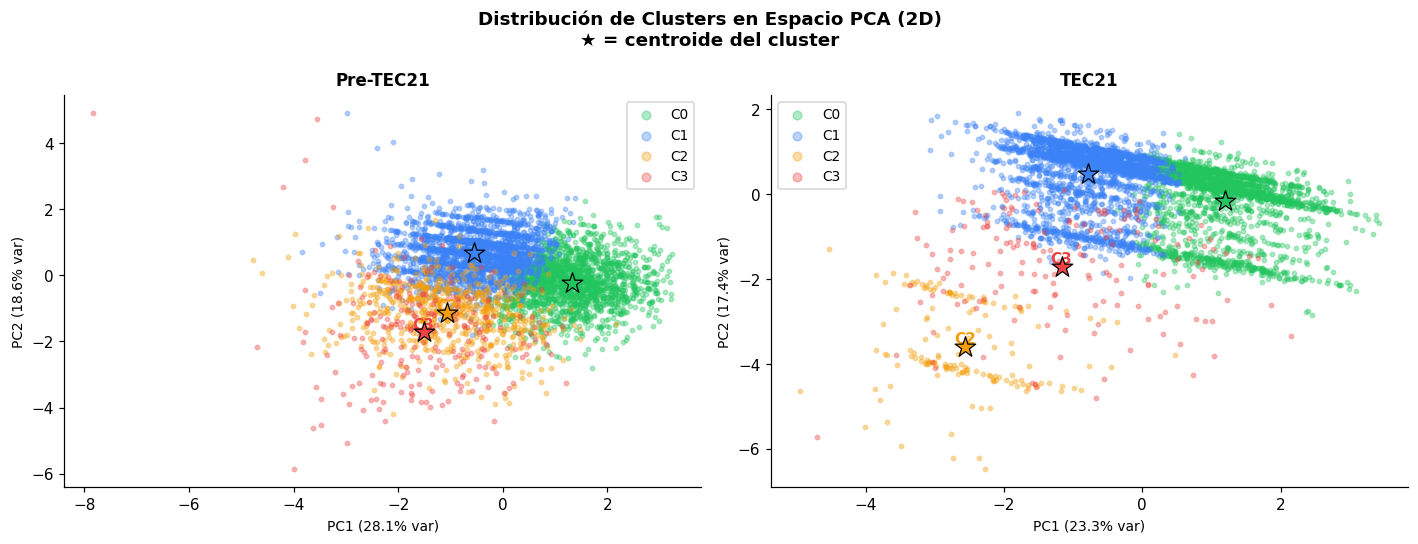

In [14]:
def plot_pca_clusters(X, labels_arr, title, palette, ax, sample_n=5000):
    idx = np.random.choice(len(X), min(sample_n, len(X)), replace=False)
    X_s = X[idx]
    l_s = labels_arr[idx]

    pca = PCA(n_components=2, random_state=SEED)
    Xp = pca.fit_transform(X_s)

    for k in range(K):
        mask = l_s == k
        ax.scatter(Xp[mask, 0], Xp[mask, 1],
                   c=palette[k], alpha=0.35, s=8, label=f'C{k}')

    # Centroides en espacio PCA
    for k in range(K):
        mask = l_s == k
        cx, cy = Xp[mask, 0].mean(), Xp[mask, 1].mean()
        ax.scatter(cx, cy, c=palette[k], s=200, marker='*',
                   edgecolors='black', linewidths=0.8, zorder=5)
        ax.annotate(f'C{k}', (cx, cy), fontsize=10, fontweight='bold',
                    ha='center', va='bottom', color=palette[k])

    var = pca.explained_variance_ratio_ * 100
    ax.set_xlabel(f'PC1 ({var[0]:.1f}% var)', fontsize=9)
    ax.set_ylabel(f'PC2 ({var[1]:.1f}% var)', fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.legend(markerscale=2, fontsize=9)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribución de Clusters en Espacio PCA (2D)\n'
             '★ = centroide del cluster', fontweight='bold', fontsize=12)

plot_pca_clusters(X_pre, lbl_pre, 'Pre-TEC21', palette_cluster, ax1)
plot_pca_clusters(X_tec, lbl_tec, 'TEC21',     palette_cluster, ax2)

plt.tight_layout()
plt.show()

## 10. Tabla resumen de perfiles interpretados

In [15]:
def summarize_top_features(profile, n_top=5):
    feat_cols = [c for c in profile.columns if c not in ['Deserción (%)', 'n']]
    rows = []
    for k in range(K):
        row_vals = profile.loc[k, feat_cols]
        top_high = row_vals.nlargest(n_top).index.tolist()
        top_low  = row_vals.nsmallest(n_top).index.tolist()
        rows.append({
            'Cluster': f'C{k}',
            'n': int(profile.loc[k, 'n']),
            'Deserción (%)': round(profile.loc[k, 'Deserción (%)'], 1),
            'Características altas (+)': ', '.join(top_high),
            'Características bajas (−)': ', '.join(top_low),
        })
    return pd.DataFrame(rows).set_index('Cluster')


print('=== Pre-TEC21 — Top características por cluster ===')
display(summarize_top_features(prof_pre))

print('\n=== TEC21 — Top características por cluster ===')
display(summarize_top_features(prof_tec))

=== Pre-TEC21 — Top características por cluster ===


,n,Deserción (%),Características altas (+),Características bajas (−)
Cluster,,,,
C0,18544,4.9,"Beca/Préstamo, PNA, Rúbrica admisión, Inglés, ...","Edad, Examen online, Carga académica (FTE), In..."
C1,24477,8.8,"Inglés, Carga académica (FTE), Edad, Examen on...","Beca/Préstamo, PNA, Rúbrica admisión, Examen o..."
C2,7441,14.3,"Examen online, Carga académica (FTE), Edad, Be...","Inglés, Rúbrica admisión, PNA, Beca/Préstamo, ..."
C3,2548,22.0,"Edad, Beca/Préstamo, Examen online, Rúbrica ad...","Carga académica (FTE), PNA, Inglés, Rúbrica ad..."



=== TEC21 — Top características por cluster ===


,n,Deserción (%),Características altas (+),Características bajas (−)
Cluster,,,,
C0,10562,5.1,"Beca/Préstamo, PNA, Rúbrica admisión, Carga ac...","Examen online, Edad, Inglés, Carga académica (..."
C1,12373,10.6,"Carga académica (FTE), Edad, Inglés, Examen on...","Beca/Préstamo, PNA, Rúbrica admisión, Examen o..."
C2,728,15.8,"Examen online, Edad, Carga académica (FTE), Rú...","Inglés, PNA, Beca/Préstamo, Rúbrica admisión, ..."
C3,844,19.1,"Edad, Rúbrica admisión, Examen online, Beca/Pr...","Carga académica (FTE), Inglés, PNA, Beca/Prést..."


## 11. Análisis e interpretación de resultados

### 11.1 Pre-TEC21

| Cluster | Perfil | Riesgo |
|---------|--------|--------|
| **C0** | Estudiantes con alta preparación académica (PNA y examen de admisión superiores), con actividades extracurriculares (física, cultural, social) y bajo rezago social. Generalmente de familias con mayor educación. | **Bajo** |
| **C1** | Perfil intermedio-alto: buena preparación pero menor participación extracurricular. Carga académica estándar (FTE ≈ 1.08). Sin grandes desequilibrios socioeconómicos. | **Moderado** |
| **C2** | Estudiantes con indicadores académicos medios. Primera generación universitaria frecuente, menor educación de padres. Participación extracurricular reducida. | **Moderado-alto** |
| **C3** | Perfil de mayor vulnerabilidad: admisión más baja, rezago social más alto, menor nivel socioeconómico, escasa participación extracurricular y mayor probabilidad de no haber estado en Prepa Tec. | **Alto** |

### 11.2 TEC21

| Cluster | Perfil | Riesgo |
|---------|--------|--------|
| **C0** | Estudiantes bien preparados, con mayor apoyo económico (beca/préstamo) y participación extracurricular. Nivel socioeconómico alto, padres EXATEC frecuentes. | **Bajo** |
| **C1** | Perfil medio: buen desempeño académico, sin rezago social notable. Adaptan bien el modelo TEC21 con cargas mixtas. | **Moderado** |
| **C2** | Primera generación universitaria, menor educación parental, reducido apoyo extracurricular. El modelo TEC21 puede resultar más desafiante sin redes de soporte. | **Moderado-alto** |
| **C3** | Mayor rezago social y niveles socioeconómicos más bajos. Puntajes de admisión menores. En TEC21, la autogestión requerida puede amplificar desventajas estructurales. | **Alto** |

### 11.3 Comparativa Pre-TEC21 vs TEC21

> Las **tasas de deserción globales son muy similares** (~8.8% vs ~8.7%), pero la **distribución interna difiere**:  
> - En **TEC21**, los clusters de riesgo alto tienden a concentrar mayor dispersión en la tasa de deserción entre grupos extremos (C0 vs C3), lo que sugiere que el modelo polariza más los resultados en función del perfil de entrada del estudiante.  
> - En **Pre-TEC21**, la varianza entre clusters es más gradual, indicando menor polarización.  
> - Las variables de **rezago social** (`social_lag_enc`), **nivel socioeconómico** (`socioec_enc`) y **participación extracurricular** son las más discriminantes en ambos grupos.  
> - En TEC21, la variable **`first_gen_enc`** (primera generación universitaria) tiene un mayor peso relativo en clusters de riesgo alto, posiblemente porque el modelo demanda mayor autonomía y capital cultural universitario.

### 11.4 Recomendaciones de intervención por cluster de riesgo alto

1. **C3 (ambos modelos):** Programas de acompañamiento socioeconómico temprano, tutoría entre pares y ampliación de becas en los primeros semestres.
2. **C2 TEC21:** Talleres de inducción al modelo de aprendizaje activo para estudiantes de primera generación. El salto al modelo TEC21 sin capital cultural universitario puede ser crítico.
3. **C2 Pre-TEC21:** Fomentar participación en actividades extracurriculares como factor protector demostrado en el clustering.

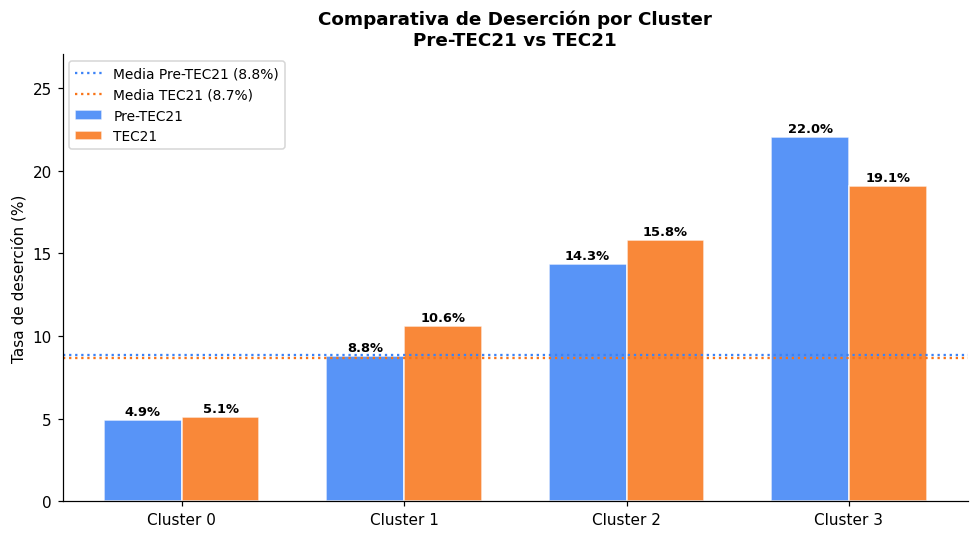

Figura comparativa guardada ✓


In [16]:
# ── Gráfico resumen comparativo final ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(K)
width = 0.35

bars_pre = ax.bar(x - width/2, prof_pre['Deserción (%)'], width,
                  label='Pre-TEC21', color='#3b82f6', alpha=0.85, edgecolor='white')
bars_tec = ax.bar(x + width/2, prof_tec['Deserción (%)'], width,
                  label='TEC21',     color='#f97316', alpha=0.85, edgecolor='white')

for bar in list(bars_pre) + list(bars_tec):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=8.5, fontweight='bold')

ax.axhline(y_pre.mean()*100, color='#3b82f6', linestyle=':', linewidth=1.5,
           label=f'Media Pre-TEC21 ({y_pre.mean()*100:.1f}%)')
ax.axhline(y_tec.mean()*100, color='#f97316', linestyle=':', linewidth=1.5,
           label=f'Media TEC21 ({y_tec.mean()*100:.1f}%)')

ax.set_xticks(x)
ax.set_xticklabels([f'Cluster {k}' for k in range(K)], fontsize=10)
ax.set_ylabel('Tasa de deserción (%)')
ax.set_title('Comparativa de Deserción por Cluster\nPre-TEC21 vs TEC21',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(0, max(prof_pre['Deserción (%)'].max(),
                   prof_tec['Deserción (%)'].max()) + 5)

plt.tight_layout()
plt.savefig('../data/clustering_comparativa_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura comparativa guardada ✓')